# 2.1 BasePlot 101: settings, layers, and multiplot

This notebook is short, and has no findings to defend — same deal as
[01.1-goad-toolkit-101](../lesson1/01.1-goad-toolkit-101.ipynb), which did the same thing for
`TransformBase`. `02.2-comparing_categories.ipynb` puts what you learn here to work on real
data; this one is just you, `BasePlot`, and a dataset small enough to hold in your head.

If subclassing is still new, read [00.1-classes](../lesson0/00.1-classes.ipynb) first —
`BasePlot` picks up exactly where that notebook leaves off, the same way `TransformBase` did.

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from goad_toolkit.visualizer import BasePlot, GroupedBarPlot, HighlightCategory, PlotSettings
from notebooktester import param

sales = pd.DataFrame({
    "region": ["north", "south", "east", "west", "north", "south", "east", "west"],
    "quarter": ["Q1", "Q1", "Q1", "Q1", "Q2", "Q2", "Q2", "Q2"],
    "revenue": [120, 95, 110, 130, 140, 100, 115, 125],
})
sales

,region,quarter,revenue
0,north,Q1,120
1,south,Q1,95
2,east,Q1,110
3,west,Q1,130
4,north,Q2,140
5,south,Q2,100
6,east,Q2,115
7,west,Q2,125


## 2.1.1 The problem it solves

A chart in a notebook starts as one seaborn call and ends as this, in every cell that draws
anything:

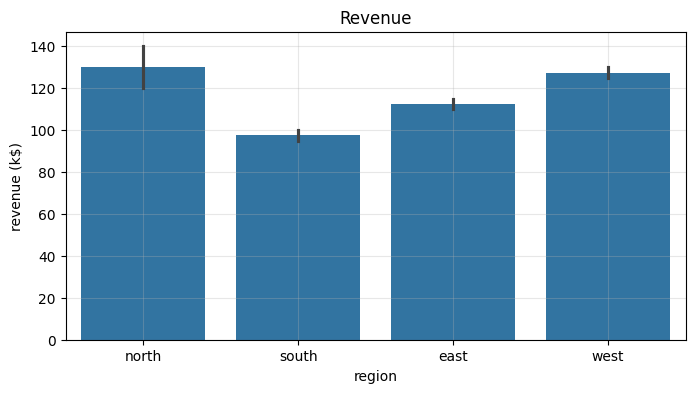

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=sales, x="region", y="revenue", ax=ax)
ax.set_title("Revenue")
ax.set_ylabel("revenue (k$)")
ax.grid(True, alpha=0.3)

If you are working with LLMs to code, you will quickly end up with a mess of styles. While you will get plots, 
it will be really difficult to maintain a codebase you can manage. 

One way to handle this is to work with more abstract (Base) classes and separate settings.

The code below is intended to help you focus more on the main theme (we are doing a bar plot, and there are reuseable settings).

This makes it easier to re-use settings, and to manage the coding process at a more abstract level.

In [45]:
class BarPlot(BasePlot):
    """A bar chart. All the styling lives in PlotSettings."""

    def build(self, data: pd.DataFrame, x: str, y: str, **kwargs):
        sns.barplot(data=data, x=x, y=y, ax=self.ax, **kwargs)
        return self.fig, self.ax


settings = PlotSettings(
    figsize=(8, 4),
    title="Revenue",
    ylabel="revenue (k$)",
    grid=True,
    grid_alpha=0.3,
)

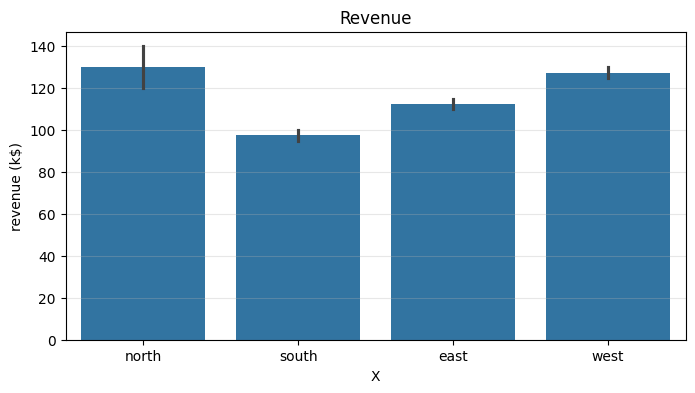

In [46]:
fig, ax = BarPlot(settings).plot(data=sales, x="region", y="revenue")

Note how `settings` gets reused as-is for a completely different grouping — no
`dataclasses.replace`, no rebuilding it, nothing. That is not a coincidence: `settings` above
never set `xlabel`, so it defaults to `None`. A `None` label means `create_figure` leaves the
axis alone and lets whichever `x=` column you actually plotted supply its own name — `"region"`
the first time, `"quarter"` the second. Only `ylabel` needed an explicit override, because
`"revenue (k$)"` says more than the bare column name `"revenue"` ever would. The rule in one
line: **leave a label unset when the column name is already the label; set it only where the
column name and the label a reader wants genuinely differ.**

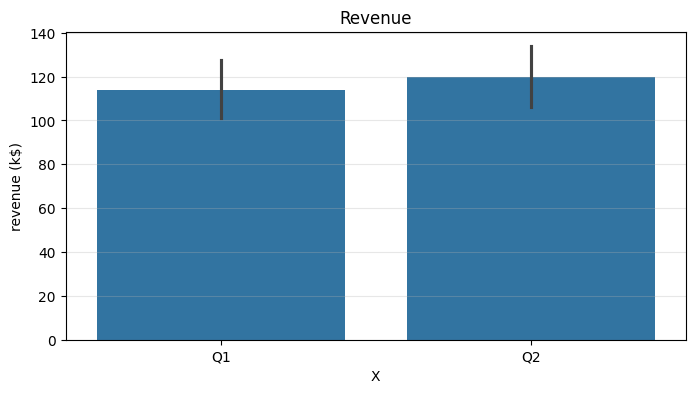

In [47]:
fig, ax = BarPlot(settings).plot(data=sales, x="quarter", y="revenue")

Leaving a label unset only helps when the column name *is* the label you want. Sometimes it
isn't, and what you actually want is the rest of `settings` untouched with one field changed —
a different title, say, for a chart that is otherwise identical. Pass the field straight into
the `plot` call: any keyword that names a `PlotSettings` field overrides that field **for
this one call**, and the shared `settings` object is untouched. That is the design's division
of labour in one line — styling lives in the settings, and the claim (a title *is* a claim)
lives at the point of use, next to the data mapping it belongs with.

In [ ]:
fig, ax = BarPlot(settings).plot(
    data=sales[sales.region == "west"], x="quarter", y="revenue",
    title="West region, on its own",
)
assert settings.title == "Revenue"  # noqa: S101 -- the shared settings really are untouched

Same picture, and now "make every figure wider" is one edit to one `PlotSettings`, not
fifteen edits to fifteen cells.

**What `plot()` guarantees.** It runs `create_figure()` before it calls your `build()`. So by
the time your code runs, you already have:

- `self.fig` and `self.ax`, created at `settings.figsize` — you never call `plt.subplots`;
- the title, axis labels and grid already applied from the settings;
- for `n_plots > 1` (2.1.2 below), a grid of subplots with the unused axes hidden.

Your `build` therefore has exactly one job — draw on `self.ax` — and one obligation: **return
`(self.fig, self.ax)`**, because that is what callers and `plot_on` chain on.

### A caveat: auto-labelling shows you the column, not a caption

`None` doesn't mean "pretty" — it means "whatever the column is called". Auto-labelling is
the right default when the column name already reads like a caption (`region`, `quarter`).
It is the wrong default the moment it doesn't, which for real datasets is most of the time.

ylabel: 'Y'


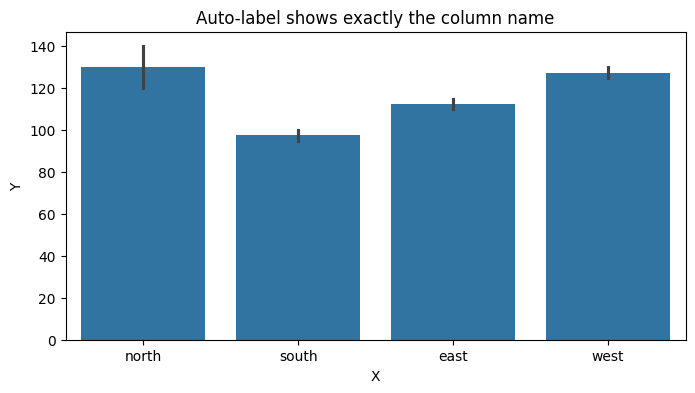

In [49]:
ugly = sales.rename(columns={"revenue": "revenue_usd_k"})
fig, ax = BarPlot(PlotSettings(figsize=(8, 4), title="Auto-label shows exactly the column name")).plot(
    data=ugly, x="region", y="revenue_usd_k"
)
print(f"ylabel: {ax.get_ylabel()!r}")

**`ylabel: 'revenue_usd_k'` on an axis is not a seaborn quirk; it is a `PlotSettings` you
forgot to fill in.** Auto-labelling saves you from writing the label when the column already
is one — it was never meant to save you from thinking about whether it is.

## 2.1.2 Multiplot

`create_figure` decides the layout before your `build` ever runs:

- `n_plots=None` (or `1`) — one axis, `settings.figsize` as given.
- `n_plots > 1` — a grid, `min(settings.max_cols, n_plots)` columns wide (three by default),
  wrapping to as many rows as it takes. Unused axes are hidden, not left blank and confusing.
  Each visible axis gets the matching entry from `settings.subplot_titles`, and the figure
  gets `settings.title` as a `suptitle` instead of a per-axis title.

`plot_on_axes(other_plot, ax, ...)` is how you put a *specific* plot instance on one axis of
that grid — the multi-panel equivalent of `plot()`.

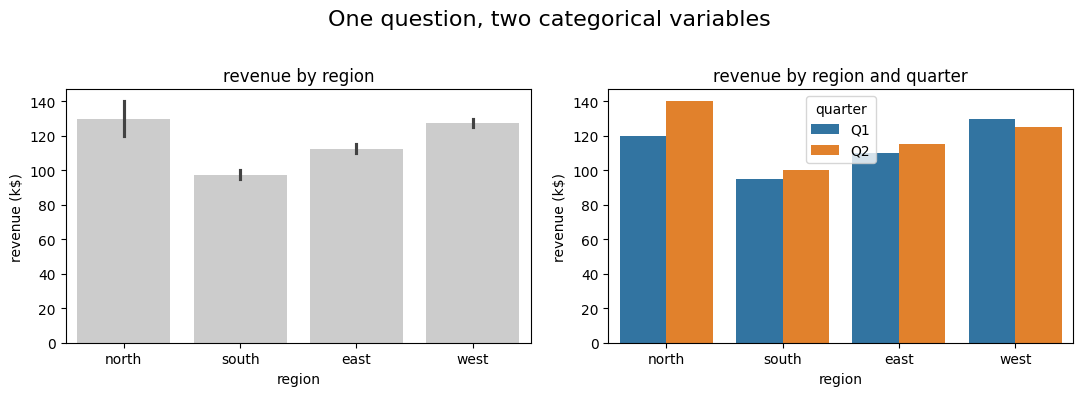

In [50]:
pair = PlotSettings(
    figsize=(11, 4),
    title="One question, two categorical variables",
    subplot_titles=["revenue by region", "revenue by region and quarter"],
    xlabel="region",
    ylabel="revenue (k$)",
)

host = BarPlot(pair)
fig, axes = host.create_figure(n_plots=2)

host.plot_on_axes(BarPlot(pair), axes[0], data=sales, x="region", y="revenue", color="#cccccc")
host.plot_on_axes(GroupedBarPlot(pair), axes[1],
                  data=sales, x="region", y="revenue", hue="quarter")

### A caveat about `max_cols`

Grid columns are `min(settings.max_cols, n_plots)`, and `max_cols` defaults to three. Four
panels at that default wrap to a row of three and a lonely fourth — rarely what a set of four
wants. Set `max_cols=2` for a square grid, or `max_cols=4` for one row of four.

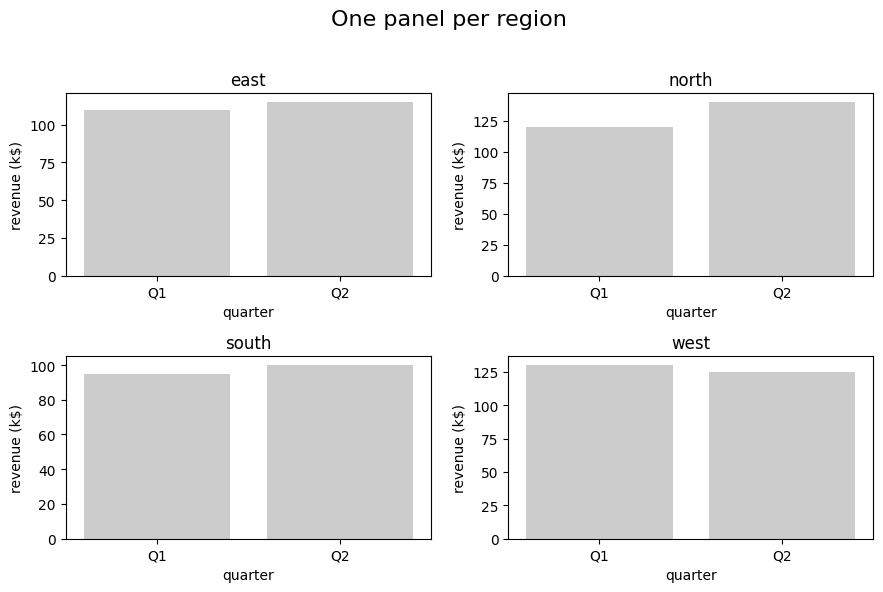

In [51]:
quad = PlotSettings(
    figsize=(9, 6),
    title="One panel per region",
    subplot_titles=sorted(sales.region.unique()),
    xlabel="quarter",
    ylabel="revenue (k$)",
    max_cols=2,
)

host = BarPlot(quad)
fig, axes = host.create_figure(n_plots=4)
for ax, region in zip(axes, sorted(sales.region.unique())):
    host.plot_on_axes(BarPlot(quad), ax,
                      data=sales[sales.region == region], x="quarter", y="revenue",
                      color="#cccccc")

That is a small-multiples figure, and it cost one extra `PlotSettings` field. Past about five
overlapping lines or a dozen bars, nobody is comparing anything on one axis — one panel per
group, with a shared y-axis, is very often the fix, and `create_figure(n_plots=n)` is what
makes it cheap enough to actually reach for. The loop above is so common that goad ships it
as a plot of its own: `FacetPlot` draws any plot once per level of a column in a single call
(with `sharey=True` in the settings for that shared y-axis) — lesson 3 uses it on real data.

## 2.1.3 Layering: `plot_on` and `plot_on_axes`

Two related methods, two different jobs:

- **`plot_on(other_plot, ...)`** hands another plot instance *this same axis* and calls its
  `plot`. Both plots end up on one set of axes. This is how a highlight, a trend line or a
  second series gets added to a chart that already exists.
- **`plot_on_axes(other_plot, ax, ...)`** hands another plot instance *a named axis inside a
  multi-panel figure* — the mechanism 2.1.2 just used twice.

`HighlightCategory` is the guideline "grey first, then one colour" as a `plot_on` layer. It
recolours the bars already on the axis, so it works over `BarPlot`, over a bare
`sns.barplot`, over anything that drew bars — it needs no cooperation from whatever drew
them.

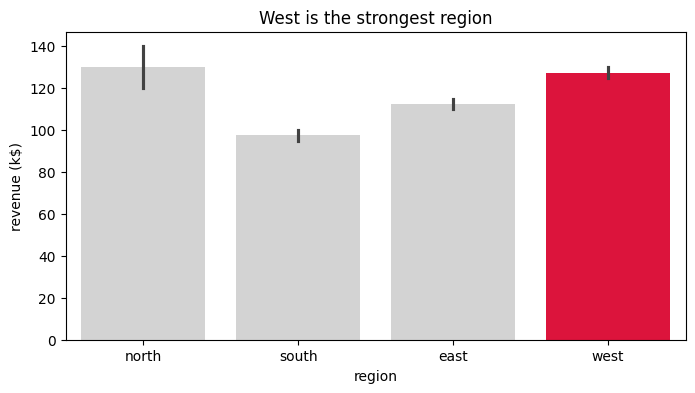

In [52]:
highlight = "west"

pointed = PlotSettings(
    figsize=(8, 4),
    title=f"{highlight.title()} is the strongest region",
    xlabel="region",
    ylabel="revenue (k$)",
    highlight=[highlight],
)

bars = BarPlot(pointed)
bars.plot(data=sales, x="region", y="revenue", color="#cccccc")
bars.plot_on(HighlightCategory(pointed))

### Two rules that keep this composable

- **Draw on `self.ax` and `self.fig`, never on `plt`.** Module-level calls like
  `plt.xticks(...)` act on matplotlib's *current* axes, which in a multi-panel figure is
  usually not the one your plot was handed. `self.ax.tick_params(axis="x", rotation=45)` is
  the explicit form, and it is the only one `plot_on_axes` can rely on.
- **`build` returns `(self.fig, self.ax)`, always — layers included.** `plot_on` and
  `plot_on_axes` both chain on that return value; a `build` that returns something else
  breaks composition for whoever calls it next.

## 2.1.4 Why not just call `sns.barplot(...)` directly?

For the chart above, honestly: you could. One `sns.barplot` call and a couple of `ax.set_*`
lines gets you the same picture in fewer lines than the class version did, and for a plot you
make once and never touch again, that overhead is real. `BasePlot` is not a rule to follow on
every single chart.

It earns its cost the moment a chart stops being one seaborn call — which happens sooner than
you'd think. `ComparePlotDate`, already shipped in `goad_toolkit.visualizer`, is two lines and
a `plot_on` twice:

```python
class ComparePlotDate(BasePlot):
    def build(self, data, x, y1, y2, date, datelabel, **kwargs):
        compare = LinePlot(self.settings)
        self.plot_on(compare, data=data, x=x, y=y1, label=y1, **kwargs)
        self.plot_on(compare, data=data, x=x, y=y2, label=y2, **kwargs)
        self.plot_on(VerticalDate(self.settings), date=date, label=datelabel)
        ...
```

Not a pseudocode sketch — run it. Two revenue channels, six months, a policy that flips which
one is winning:

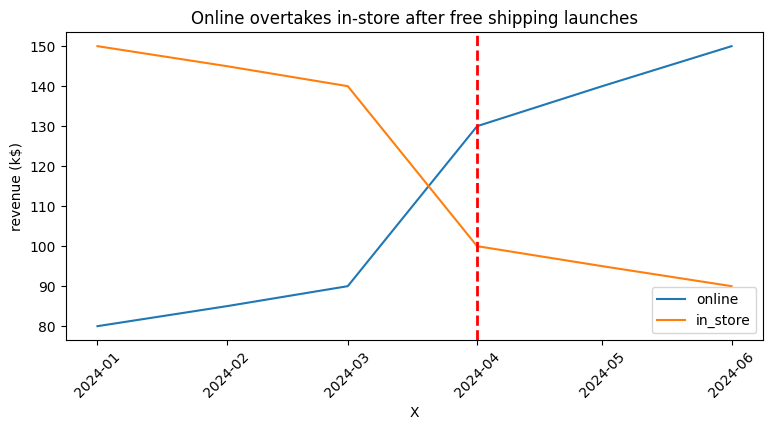

In [53]:
from goad_toolkit.visualizer import ComparePlotDate

timeline = pd.DataFrame({
    "month": pd.date_range("2024-01-01", periods=6, freq="MS"),
    "online": [80, 85, 90, 130, 140, 150],
    "in_store": [150, 145, 140, 100, 95, 90],
})

compare_settings = PlotSettings(
    figsize=(9, 4),
    title="Online overtakes in-store after free shipping launches",
    ylabel="revenue (k$)",
)
fig, ax = ComparePlotDate(compare_settings).plot(
    data=timeline, x="month", y1="online", y2="in_store",
    date="2024-04-01", datelabel="free shipping launches",
)

Three method calls — `plot`, then two implicit `plot_on`s you never wrote — produced two
labelled lines, a legend, and an annotated date, and `ComparePlotDate` itself is nothing but
composition: no `sns` call of its own, no axis code, just `LinePlot` called twice and
`VerticalDate` laid over the top. That is the payoff `BasePlot` is actually for: not this one
chart, but the fact that *this* chart cost nothing to write once `LinePlot` and `VerticalDate`
already existed.

Two lines you drew today (a highlight, a comparison) become three or four compositions
tomorrow, each one a `plot_on` call rather than a rewritten `sns` incantation. `DecomposePlot`
overrides `plot` entirely because it needs to know its panel count (four, fixed) before the
figure exists; `PlotFits` loops over an arbitrary number of fitted distributions, picking a
colour per panel by which one won. None of that is expressible as "one seaborn call" — it is
expressible as small plots stacked, which is what `BasePlot` is *for*.

Read the rest yourself before taking that on faith: `goad_list_concepts` and
`goad_get_concept("03-plot-composition")` (the `goad` MCP tool this repo already has
connected) walk through the composition examples in full, with the reasoning behind each one.
The library's own source — `goad_toolkit/visualizer.py` — is worth a skim too, once you've
written a subclass yourself; it reads very differently once "the fifteen lines I wrote in
2.1.1" is your reference point for what a `BasePlot` subclass *is*.

## 2.1.5 The case for this when you're using an LLM

Say what you're actually going to do: ask an assistant to write some of your chart code. That
changes the calculus, not away from `BasePlot` but further towards it.

An LLM handed "plot revenue by region" with no other context invents styling each time —
a palette here, a grid there, axis labels sometimes present and sometimes not, one cell using
`figsize=(10, 6)` and the next `(8, 5)` for no reason anyone could defend. Ask for the same
chart in a notebook that already has fifteen ad hoc `sns` cells and you get a sixteenth style,
because there was nothing to be consistent *with*.

A `PlotSettings` + `BasePlot` contract gives it something to be consistent with. "Write a
`BasePlot` subclass with this `build` signature, styled by this `PlotSettings`" is a spec an
LLM can satisfy exactly, the same way a type hint is a spec a compiler can check — and the
result composes with `plot_on` and `plot_on_axes` instead of sitting alone as one more
`sns` call nobody else's code can reach. That matters most for exactly the code an LLM is
often asked to help with: a pipeline that has to keep working next month, on next month's
data, without you rereading every cell to see what changed. Standardise the settings and the
extension point once, and both a human and an LLM can extend the library without
re-deriving the makeup every time.

## 2.1.6 Your turn

Write a `BasePlot` **layer** — a subclass that draws nothing new, only recolours what is
already on the axis. `HighlightCategory` above is the model: pick out the tallest bar
(`patch.get_height()`) and set its `facecolor` to something other than the rest.

```python
class MaxHighlight(BasePlot):
    def build(self, color: str = "crimson", **kwargs):
        # find the tallest patch on self.ax, recolour it; leave the others grey
        ...
        return self.fig, self.ax
```

Apply it with `bars2.plot_on(MaxHighlight(settings))` in the cell below, the same way
`HighlightCategory` was applied above.

AssertionError: define a MaxHighlight layer above and apply it with bars2.plot_on(...), so the bars are not all the same colour

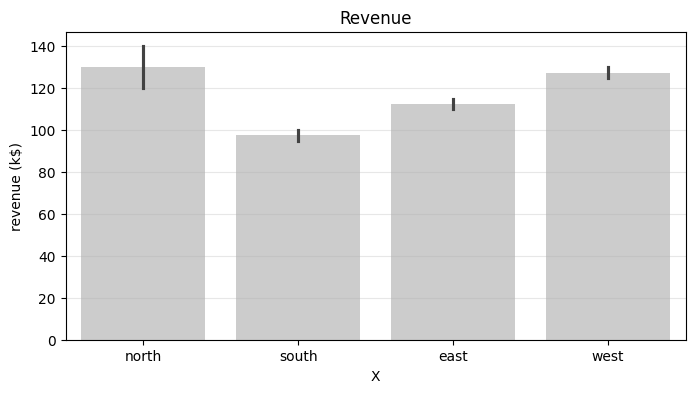

In [54]:
bars2 = BarPlot(settings)
bars2.plot(data=sales, x="region", y="revenue", color="#cccccc")

# >>> Your turn: define MaxHighlight above, then apply it here. <<<
#
# bars2.plot_on(MaxHighlight(settings))

MIN_DISTINCT_COLORS = param(2, test=1)
colors = {tuple(patch.get_facecolor()) for patch in bars2.ax.patches if patch.get_width() != 0}
assert len(colors) >= MIN_DISTINCT_COLORS, (  # noqa: S101 -- the check *is* the point here
    "define a MaxHighlight layer above and apply it with bars2.plot_on(...), so the bars "
    "are not all the same colour"
)
print(f"{len(colors)} distinct bar colour(s)")

---

**Where this goes next.** `02.2-comparing_categories.ipynb` derives a `BarPlot` again — on
real data this time, penguins and the Titanic — and uses it, `GroupedBarPlot`, `HeatmapPlot`
and `HighlightCategory` to ask the question this lesson is actually about: how do groups
differ, and how does that comparison go wrong.